In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [3]:
df = pd.read_csv("../data/processed/telco_clean.csv")

print(df.shape)
df.head()


(7043, 29)


,CustomerID,City,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,...,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Revenue_Per_Month,Tenure_Group,Charge_Group
0,3668-QPYBK,Los Angeles,Male,No,No,No,2,Yes,No,DSL,...,53.85,108.15,Yes,1,86,3239,Competitor made better offer,36.050000,0-1 Year,Medium
1,9237-HQITU,Los Angeles,Female,No,No,Yes,2,Yes,No,Fiber optic,...,70.70,151.65,Yes,1,67,2701,Moved,50.550000,0-1 Year,High
2,9305-CDSKC,Los Angeles,Female,No,No,Yes,8,Yes,Yes,Fiber optic,...,99.65,820.50,Yes,1,86,5372,Moved,91.166667,0-1 Year,Very High
3,7892-POOKP,Los Angeles,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,...,104.80,3046.05,Yes,1,84,5003,Moved,105.036207,2-4 Years,Very High
4,0280-XJGEX,Los Angeles,Male,No,No,Yes,49,Yes,Yes,Fiber optic,...,103.70,5036.30,Yes,1,89,5340,Competitor had better devices,100.726000,4-6 Years,Very High


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 7043
Columns: 29
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   City               7043 non-null   object 
 2   Gender             7043 non-null   object 
 3   Senior Citizen     7043 non-null   object 
 4   Partner            7043 non-null   object 
 5   Dependents         7043 non-null   object 
 6   Tenure Months      7043 non-null   int64  
 7   Phone Service      7043 non-null   object 
 8   Multiple Lines     7043 non-null   object 
 9   Internet Service   7043 non-null   object 
 10  Online Security    7043 non-null   object 
 11  Online Backup      7043 non-null   object 
 12  Device Protection  7043 non-null   object 
 13  Tech Support       7043 non-null   object 
 14  Streaming TV       7043 non-null   object 
 15  Streaming Movies   7043 non-null   object 
 16  C

In [5]:
churn_counts = df["Churn Label"].value_counts()

print(churn_counts)

churn_rate = (
    df["Churn Label"]
    .value_counts(normalize=True)
    * 100
)

print(churn_rate)

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64
Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


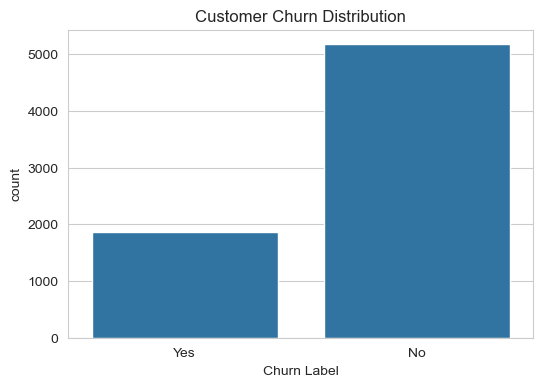

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Churn Label"
)

plt.title("Customer Churn Distribution")
plt.show()

In [7]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
)*100

contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


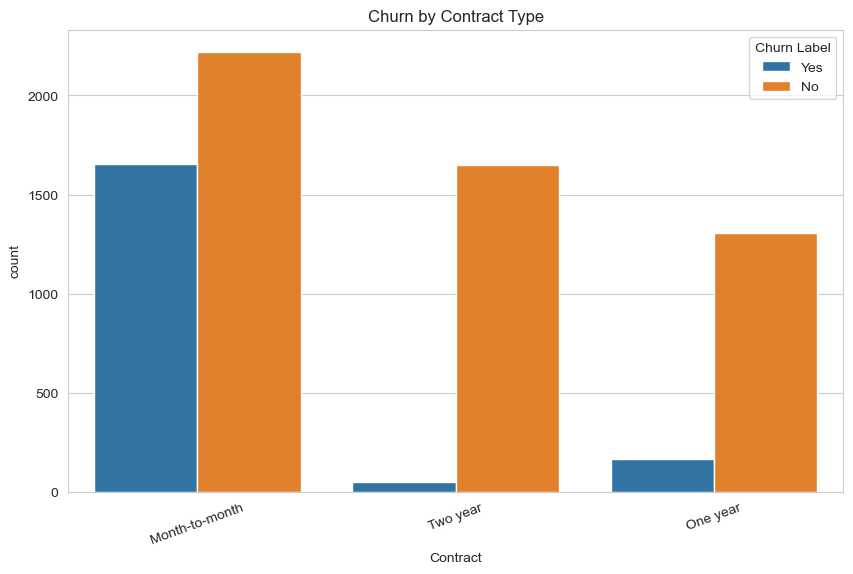

In [8]:
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn Label"
)

plt.title("Churn by Contract Type")
plt.xticks(rotation=20)
plt.show()

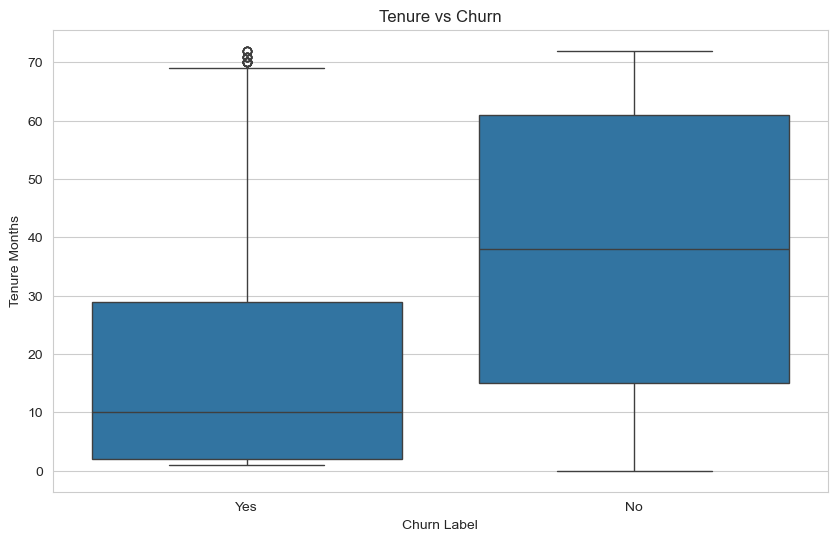

In [9]:
sns.boxplot(
    data=df,
    x="Churn Label",
    y="Tenure Months"
)

plt.title("Tenure vs Churn")
plt.show()

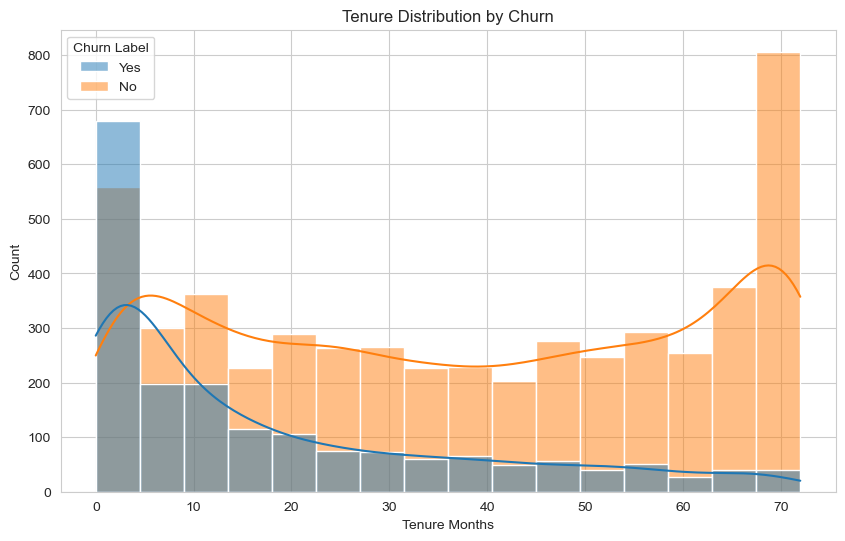

In [10]:
sns.histplot(
    data=df,
    x="Tenure Months",
    hue="Churn Label",
    kde=True
)

plt.title("Tenure Distribution by Churn")
plt.show()

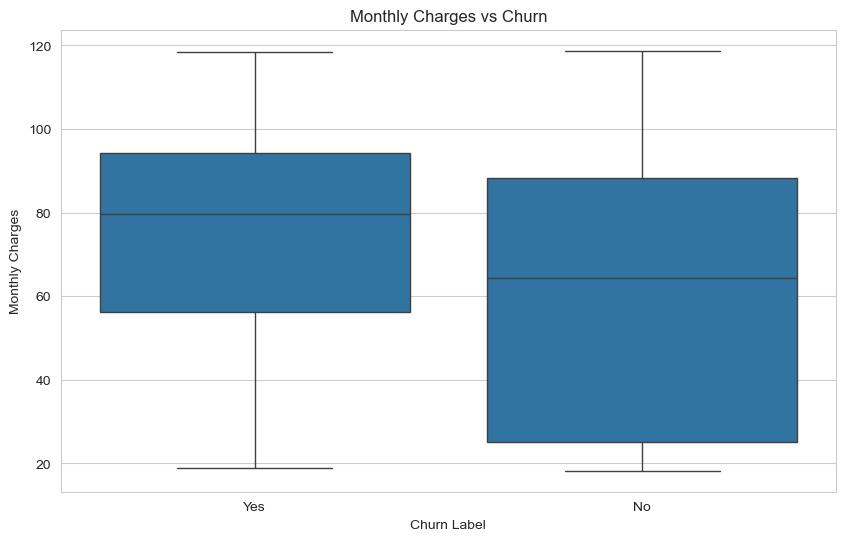

In [11]:
sns.boxplot(
    data=df,
    x="Churn Label",
    y="Monthly Charges"
)

plt.title("Monthly Charges vs Churn")
plt.show()

In [12]:
revenue_at_risk = df[
    df["Churn Label"]=="Yes"
]["Monthly Charges"].sum()

print(
    f"Revenue At Risk: ${revenue_at_risk:,.2f}"
)

Revenue At Risk: $139,130.85


In [13]:
internet_churn = pd.crosstab(
    df["Internet Service"],
    df["Churn Label"],
    normalize="index"
)*100

internet_churn

Churn Label,No,Yes
Internet Service,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


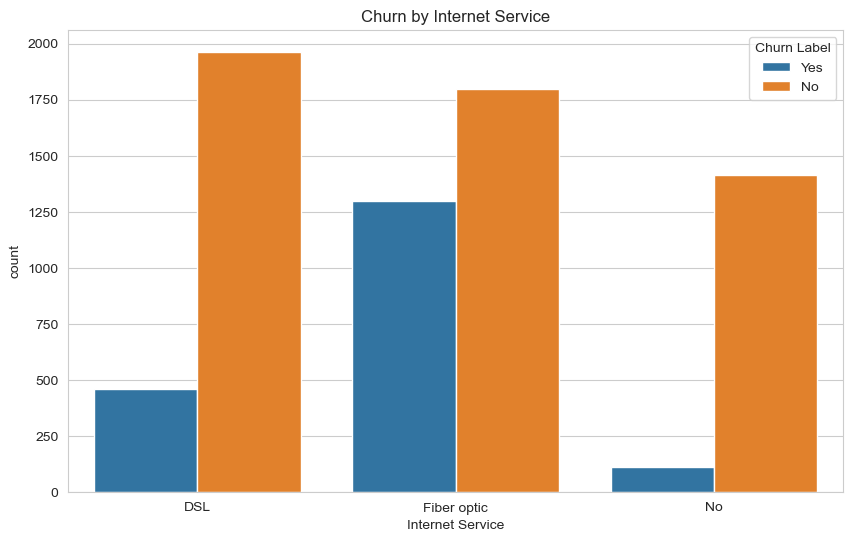

In [14]:
sns.countplot(
    data=df,
    x="Internet Service",
    hue="Churn Label"
)

plt.title("Churn by Internet Service")
plt.show()

In [15]:
payment_churn = pd.crosstab(
    df["Payment Method"],
    df["Churn Label"],
    normalize="index"
)*100

payment_churn.sort_values(
    by="Yes",
    ascending=False
)

Churn Label,No,Yes
Payment Method,,
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101


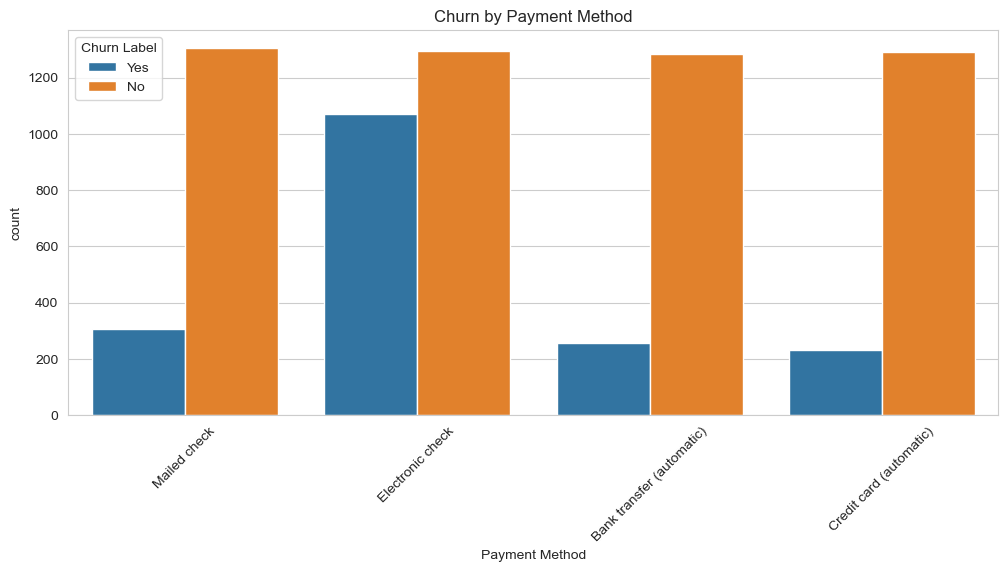

In [16]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="Payment Method",
    hue="Churn Label"
)

plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

In [17]:
churn_reasons = (
    df[df["Churn Label"]=="Yes"]
    ["Churn Reason"]
    .value_counts()
    .head(10)
)

churn_reasons

Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Name: count, dtype: int64

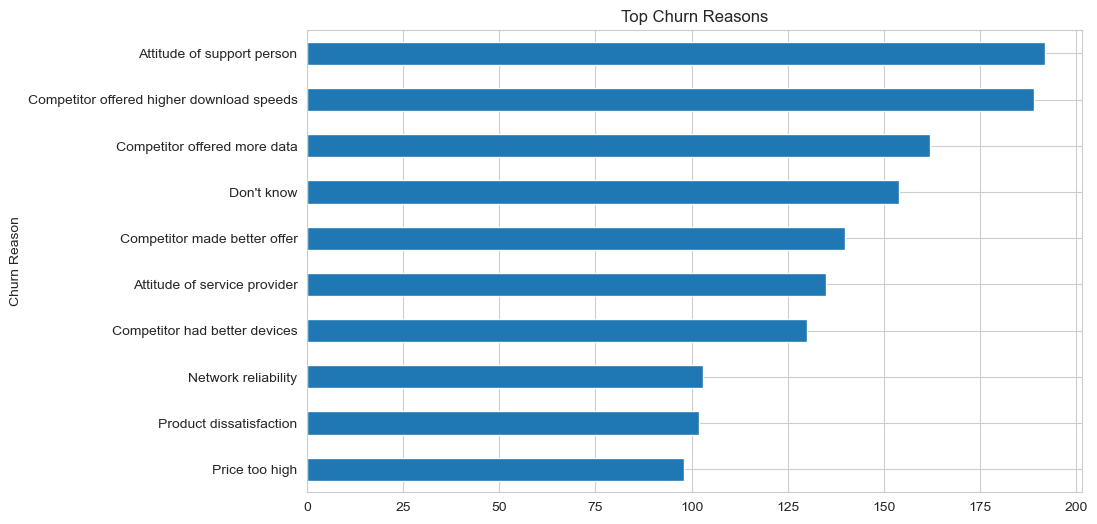

In [18]:
plt.figure(figsize=(10,6))

churn_reasons.sort_values().plot(
    kind="barh"
)

plt.title("Top Churn Reasons")
plt.show()

In [19]:
df.groupby(
    "Churn Label"
)["CLTV"].mean()

Churn Label
No     4490.921337
Yes    4149.414660
Name: CLTV, dtype: float64

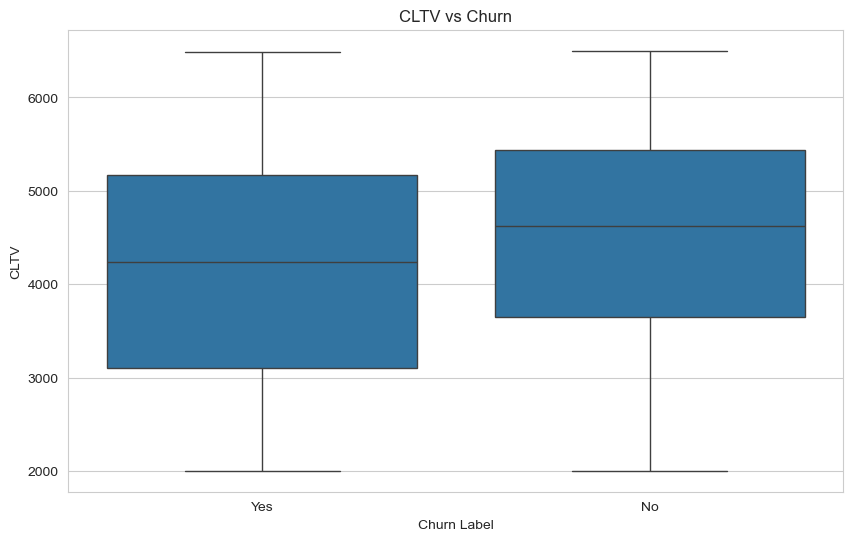

In [20]:
sns.boxplot(
    data=df,
    x="Churn Label",
    y="CLTV"
)

plt.title("CLTV vs Churn")
plt.show()

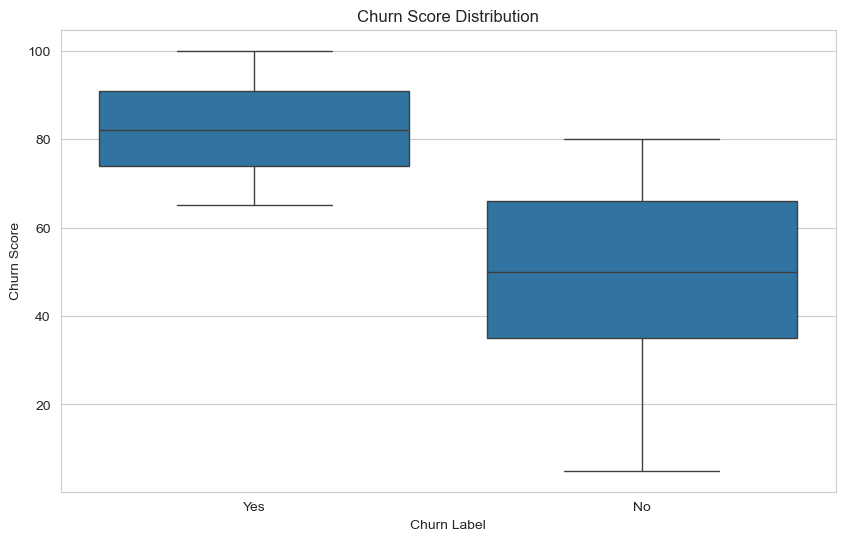

In [21]:
sns.boxplot(
    data=df,
    x="Churn Label",
    y="Churn Score"
)

plt.title("Churn Score Distribution")
plt.show()

In [22]:
numerical_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV",
    "Churn Score"
]

corr = df[numerical_cols].corr()

corr

,Tenure Months,Monthly Charges,Total Charges,CLTV,Churn Score
Tenure Months,1.000000,0.247900,0.825880,0.396406,-0.224987
Monthly Charges,0.247900,1.000000,0.651065,0.098693,0.133754
Total Charges,0.825880,0.651065,1.000000,0.341837,-0.124312
CLTV,0.396406,0.098693,0.341837,1.000000,-0.079782
Churn Score,-0.224987,0.133754,-0.124312,-0.079782,1.000000


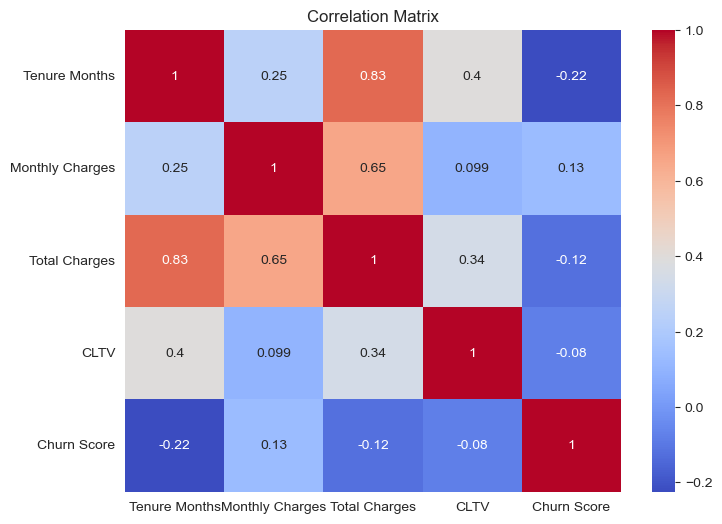

In [23]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

1. Overall churn rate is approximately X%.

2. Month-to-month customers have the highest churn rate.

3. Customers with shorter tenure are more likely to churn.

4. Fiber optic customers show higher churn than DSL customers.

5. Electronic check users have higher churn rates.

6. Revenue at risk due to churn is $XXXXX per month.

7. Competitor offerings and pricing are major churn drivers.

8. Churned customers generally have lower tenure.

9. High churn scores are strongly associated with churned customers.

10. Targeting high-risk customers early could improve retention.